# PHASE 2 — Second dataset, diagnostic value, and the missing number

Three reviewer items in one run. Items 4 and 5 (the Table 5/6 explanation and the reframe) are
already in the manuscript and needed no compute.

**Item 1 — one dataset is now the binding constraint.** $\rho$ is a property of
(suite × task × corpus), and every estimate so far comes from one corpus. Magnetic Tile needs only
its folds rebuilt without the discarded pHash grouping. Two datasets turns *"we measured $\rho$
once"* into *"$\rho$ falls in this range across two tasks"*, which is the difference between an
observation and a finding.

**Item 2 — the diagnostic justification for SDI-C is one anecdote.** Section 6.8 shows SDI-C and
ImageNet-C rank backbones identically, then rescues SDI-C on the vignetting failure: one family,
observed four non-independent ways. §4 replaces that with a systematic test.

**Item 6 — the missing suite ICC.** Cell 18 of Phase 1.1 lost its output. Recovered in §5.

---

## The test for item 2, stated before running it

The question is not whether SDI-C families *differ* from ImageNet-C families — they trivially do.
It is whether any SDI-C family carries information that the ImageNet-C suite **cannot reconstruct**.

For every family we form a per-image damage vector: the mean increase in negative log-likelihood
under that family, relative to clean, for each of the 900 images. That is 900 numbers describing
*which images this corruption hurts*. We then regress each SDI-C family's damage vector on the
full set of fifteen ImageNet-C damage vectors and record the cross-validated $R^2$.

* $R^2$ near 1 — the family is a linear combination of ImageNet-C families. Redundant.
* $R^2$ low — no combination of ImageNet-C corruptions reproduces which images this one damages.
  It measures something the generic suite does not, and that is a diagnostic contribution rather
  than an assertion of one.

Cross-validated, because with 15 predictors and 900 observations an in-sample $R^2$ would be
optimistic. The prediction registered in advance: vignetting and lens contamination should be the
least reconstructable, since no ImageNet-C family models a contact-optics effect. **If that
prediction fails, the manuscript must drop the diagnostic rescue and demote SDI-C outright.**

## Compute

| Stage | Cost |
|---|---|
| Magnetic Tile: index, rebuild folds, near-duplicate validity check | ~4 min |
| Magnetic Tile: SDI-C extraction, 1,344 images × 61 conditions × 5 backbones | ~30 min |
| NEU features: reused from disk if `/content/sdic/feats_phase1` survives, else re-extracted | 0 or ~66 min |
| Analysis: $\rho$ for both datasets, suite ICC, span regression | ~5 min |

If the Phase 1.1 runtime is still alive, or you kept the 1.02 GB cache, this is a 40-minute run.

## 0. Core module

In [1]:
CORE_V2 = r"""
import math, hashlib
import numpy as np, cv2

def _clip(x): return np.clip(x, 0, 1)
def _mask3(mask, x): return mask[..., None] if x.ndim == 3 else mask

# ------------------------------------------------------------------ optics --
def defocus_blur(x, s):
    r = [1, 2, 3, 5, 7][s-1]
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1)).astype(np.float32)
    return _clip(cv2.filter2D(x, -1, k/k.sum()))

def motion_blur(x, s):
    ksz = [5, 9, 13, 19, 25][s-1]
    ang = np.random.uniform(0, 180)
    k = np.zeros((ksz, ksz), np.float32); k[ksz//2, :] = 1.0
    M = cv2.getRotationMatrix2D((ksz/2-.5, ksz/2-.5), ang, 1.0)
    k = cv2.warpAffine(k, M, (ksz, ksz))
    return _clip(cv2.filter2D(x, -1, k/k.sum()))

def vignetting(x, s):
    st = [0.15, 0.30, 0.45, 0.62, 0.80][s-1]
    h, w = x.shape[:2]; yy, xx = np.mgrid[0:h, 0:w]
    r = np.sqrt(((xx-w/2)/(w/2))**2 + ((yy-h/2)/(h/2))**2)
    m = np.clip(1 - st*np.clip(r-0.4, 0, None)/0.6, 0, 1).astype(np.float32)
    return _clip(x * _mask3(m, x))

def lens_contamination(x, s):
    n = [3, 7, 13, 22, 34][s-1]; h, w = x.shape[:2]
    blurred = cv2.GaussianBlur(x, (0, 0), sigmaX=max(1.0, min(h, w)/40))
    mask = np.zeros((h, w), np.float32)
    for _ in range(n):
        c = (np.random.randint(0, w), np.random.randint(0, h))
        rad = np.random.randint(max(2, int(0.015*w)), max(4, int(0.07*w)))
        cv2.circle(mask, c, rad, 1.0, -1, lineType=cv2.LINE_AA)
    mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=max(1.0, min(h, w)/60))
    m = _mask3(mask, x)                       # guard: 2-D input used to broadcast to (H,W,W)
    return _clip((x*(1-m) + blurred*m) * (1 - 0.25*m))

def vibration_jitter(x, s):
    amp = [0.6, 1.4, 2.6, 4.2, 6.5][s-1]; h, w = x.shape[:2]
    dx, dy = np.random.uniform(-amp, amp, 2)
    out = cv2.warpAffine(x, np.float32([[1, 0, dx], [0, 1, dy]]), (w, h),
                         flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    ksz = int(max(3, 2*round(amp)+1))
    k = np.zeros((ksz, ksz), np.float32); k[ksz//2, :] = 1.0
    M2 = cv2.getRotationMatrix2D((ksz/2-.5, ksz/2-.5), math.degrees(math.atan2(dy, dx)), 1.0)
    k = cv2.warpAffine(k, M2, (ksz, ksz))
    return _clip(cv2.filter2D(out, -1, k/max(k.sum(), 1e-8)))

# ------------------------------------------------------------------ sensor --
def gaussian_noise(x, s):
    return _clip(x + np.random.normal(0, [0.03, 0.06, 0.10, 0.16, 0.24][s-1], x.shape))

def shot_noise(x, s):
    lam = [80, 35, 15, 7, 3][s-1]
    return _clip(np.random.poisson(x*lam)/float(lam))

def scanline_banding(x, s):
    amp = [0.03, 0.06, 0.11, 0.17, 0.25][s-1]; h = x.shape[0]
    period = np.random.uniform(3, 22); phase = np.random.uniform(0, 2*np.pi)
    b = (1 + amp*np.sin(2*np.pi*np.arange(h)/period + phase)).astype(np.float32)
    return _clip(x * (b[:, None, None] if x.ndim == 3 else b[:, None]))

# ------------------------------------------------------------- photometric --
def illumination_gradient(x, s):
    st = [0.10, 0.20, 0.32, 0.46, 0.62][s-1]; h, w = x.shape[:2]
    ang = np.random.uniform(0, 2*np.pi); yy, xx = np.mgrid[0:h, 0:w]
    u = (xx/w-.5)*np.cos(ang) + (yy/h-.5)*np.sin(ang)
    g = (1 + st*u/(np.abs(u).max()+1e-8)).astype(np.float32)
    return _clip(x * _mask3(g, x))

def brightness_drift(x, s):
    # v2: gamma instead of an additive offset. Gamma maps [0,1] -> [0,1] and CANNOT clip.
    # v1 saturated 36.8% of pixels at severity 5 on Magnetic Tile, which destroyed dynamic
    # range rather than shifting brightness and made the top of the ladder meaningless.
    g = [1.12, 1.26, 1.45, 1.72, 2.05][s-1]
    if np.random.rand() < 0.5: g = 1.0/g
    return _clip(np.power(_clip(x), g))

def contrast_loss(x, s):
    g = [0.80, 0.65, 0.50, 0.36, 0.24][s-1]
    m = x.mean(axis=(0, 1), keepdims=True)
    return _clip((x-m)*g + m)

# ---------------------------------------------------------------- pipeline --
def jpeg_compression(x, s):
    q = [70, 50, 32, 18, 9][s-1]
    src = (x[..., ::-1]*255).astype(np.uint8) if x.ndim == 3 else (x*255).astype(np.uint8)
    _, enc = cv2.imencode(".jpg", src, [int(cv2.IMWRITE_JPEG_QUALITY), q])
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR if x.ndim == 3 else cv2.IMREAD_GRAYSCALE)
    return (dec[..., ::-1] if x.ndim == 3 else dec).astype(np.float32)/255.

CORRUPTIONS = {
    "defocus_blur": defocus_blur, "motion_blur": motion_blur, "vignetting": vignetting,
    "lens_contamination": lens_contamination, "vibration_jitter": vibration_jitter,
    "gaussian_noise": gaussian_noise, "shot_noise": shot_noise,
    "scanline_banding": scanline_banding, "illumination_gradient": illumination_gradient,
    "brightness_drift": brightness_drift, "contrast_loss": contrast_loss,
    "jpeg": jpeg_compression,
}
TRAIN_FAMILIES = ["defocus_blur", "gaussian_noise", "illumination_gradient",
                  "jpeg", "lens_contamination", "scanline_banding"]
TEST_FAMILIES  = ["motion_blur", "shot_noise", "brightness_drift",
                  "contrast_loss", "vignetting", "vibration_jitter"]
SEVERITIES = [1, 2, 3, 4, 5]
CONDITIONS = [("clean", 0)] + [(f, s) for f in CORRUPTIONS for s in SEVERITIES]


def corruption_seed(image_id, family, severity=None):
    # Depends on (image_id, family) only, NOT severity: nuisance parameters (blur angle,
    # banding period, blob positions, gradient orientation) stay fixed so that severity is
    # the sole varying factor. Seeding on severity too made scanline_banding score 0.20.
    h = hashlib.sha256(f"{image_id}|{family}".encode()).digest()
    return int.from_bytes(h[:4], "little")


def apply_corruption(img_u8, family, severity, image_id=None, seed=None):
    if family == "clean":
        return img_u8
    if seed is None and image_id is not None:
        seed = corruption_seed(image_id, family)
    st = None
    if seed is not None:
        st = np.random.get_state(); np.random.seed(seed % (2**32))
    try:
        out = CORRUPTIONS[family](img_u8.astype(np.float32)/255., severity)
    finally:
        if st is not None: np.random.set_state(st)
    return (np.clip(out, 0, 1)*255).astype(np.uint8)


# ------------------------------------------------------- quality descriptors -
def _gray(im):
    g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY) if im.ndim == 3 else im
    return g.astype(np.float32)/255.

def _sharp(im): return float(cv2.Laplacian(_gray(im), cv2.CV_32F).var())

def _noise(im):
    g = _gray(im); h, w = g.shape
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], np.float32)
    return float(np.abs(cv2.filter2D(g, -1, M)).sum()*math.sqrt(math.pi/2) /
                 (6*max(w-2, 1)*max(h-2, 1)))

def _block(im):
    dh = np.abs(np.diff(_gray(im), axis=1))
    on = dh[:, 7::8].mean() if dh.shape[1] > 8 else 0.0
    return float(on/(dh.mean()+1e-8) - 1.0)

def _hf(im):
    g = _gray(im); f = np.abs(np.fft.fftshift(np.fft.fft2(g))); h, w = g.shape
    cy, cx = h//2, w//2; r = max(4, min(h, w)//8)
    return float(1.0 - f[cy-r:cy+r, cx-r:cx+r].sum()/(f.sum()+1e-8))


def quality_descriptor(img_u8):
    # 8-d ABSOLUTE no-reference descriptor (unchanged from v1).
    g = _gray(img_u8); h, w = g.shape
    if img_u8.ndim == 3:
        rg = img_u8[..., 0].astype(np.float32) - img_u8[..., 1]
        yb = .5*(img_u8[..., 0].astype(np.float32) + img_u8[..., 1]) - img_u8[..., 2]
        colour = float((np.sqrt(rg.std()**2 + yb.std()**2)
                        + .3*np.sqrt(rg.mean()**2 + yb.mean()**2))/255.)
    else:
        colour = 0.0
    cen = g[h//4:3*h//4, w//4:3*w//4]
    per = (g.sum()-cen.sum())/max(g.size-cen.size, 1)
    v = np.array([math.log1p(max(_sharp(img_u8), 0.)*1e3), _hf(img_u8),
                  math.log1p(max(_noise(img_u8), 0.)*1e3), _block(img_u8),
                  float(g.mean()), float(g.std()), colour,
                  float(cen.mean()/(per+1e-8))], np.float32)
    return np.nan_to_num(v, nan=0., posinf=0., neginf=0.)


def quality_descriptor_relative(img_u8):
    # 8-d PERTURBATION-RESPONSE descriptor: how much does a statistic move when a known
    # perturbation is applied? Higher severity signal than the absolute set (0.324 vs 0.236
    # on the synthetic benchmark) but NO reduction in class leakage on its own -- ratios
    # remove the absolute texture level, not the spectral shape. Use with class-conditional
    # standardisation, never alone.
    g8 = (_gray(img_u8)*255).astype(np.uint8); eps = 1e-8
    b = cv2.GaussianBlur(g8, (0, 0), 1.5)
    dn = cv2.resize(cv2.resize(g8, (max(2, g8.shape[1]//2), max(2, g8.shape[0]//2)),
                               interpolation=cv2.INTER_AREA),
                    (g8.shape[1], g8.shape[0]), interpolation=cv2.INTER_LINEAR)
    rn = np.random.default_rng(12345)
    nz = np.clip(g8.astype(np.float32) + rn.normal(0, 12, g8.shape), 0, 255).astype(np.uint8)
    _, e = cv2.imencode(".jpg", g8, [int(cv2.IMWRITE_JPEG_QUALITY), 40])
    jp = cv2.imdecode(e, cv2.IMREAD_GRAYSCALE)
    kh = np.zeros((9, 9), np.float32); kh[4, :] = 1/9.
    hb = cv2.filter2D(g8.astype(np.float32), -1, kh).astype(np.uint8)
    vb = cv2.filter2D(g8.astype(np.float32), -1, kh.T).astype(np.uint8)
    x = g8.astype(np.float32)/255.
    v = np.array([
        math.log((_sharp(g8)+eps)/(_sharp(b)+eps)),
        math.log((_sharp(g8)+eps)/(_sharp(dn)+eps)),
        math.log((_noise(nz)+eps)/(_noise(g8)+eps)),
        _block(jp) - _block(g8),
        float(((x+0.25) > 1.0).mean() + ((x-0.25) < 0.0).mean()),
        abs(math.log((_sharp(hb)+eps)/(_sharp(vb)+eps))),
        math.log((_hf(g8)+eps)/(_hf(b)+eps)),
        math.log((_gray(g8).std()+eps)/(_gray(b).std()+eps)),
    ], np.float32)
    return np.nan_to_num(v, nan=0., posinf=0., neginf=0.)


QUALITY_NAMES = ["sharpness", "hf_energy", "noise", "blockiness",
                 "luminance_mean", "luminance_std", "colourfulness", "vignette_ratio"]
RELATIVE_NAMES = ["blur_headroom", "resolution_headroom", "noise_headroom",
                  "compression_headroom", "clipping_headroom", "blur_anisotropy",
                  "hf_retention", "contrast_retention"]
QUALITY_DIM = 8


class ClassConditionalStandardiser:
    # z = (q - mu_c) / sigma_c, with mu_c and sigma_c estimated on DEVELOPMENT data only.
    #
    # Rationale: degradation is relative. A blurry-looking crazing image and a sharp-looking
    # patches image can have identical absolute sharpness; what makes one degraded is that it
    # is blurrier than crazing images normally are. Removing the class-conditional mean strips
    # the content component and leaves the deviation-from-typical -- which is the degradation.
    #
    # At test time c is the model's own prediction. There is no feedback loop: a per-image
    # scalar temperature cannot change the argmax, so the prediction is fixed before the
    # calibrator runs.
    def __init__(self, n_classes):
        self.n_classes = n_classes; self.mu = None; self.sd = None

    def fit(self, q, y):
        d = q.shape[1]
        self.mu = np.zeros((self.n_classes, d), np.float32)
        self.sd = np.ones((self.n_classes, d), np.float32)
        gm, gs = q.mean(0), q.std(0) + 1e-6
        for c in range(self.n_classes):
            m = (y == c)
            if m.sum() >= 5:                 # fall back to global stats for tiny classes
                self.mu[c] = q[m].mean(0); self.sd[c] = q[m].std(0) + 1e-6
            else:
                self.mu[c] = gm; self.sd[c] = gs
        return self

    def transform(self, q, y_pred):
        y_pred = np.asarray(y_pred).astype(int)
        return ((q - self.mu[y_pred]) / self.sd[y_pred]).astype(np.float32)
"""
print(f"embedded core module: {len(CORE_V2.splitlines())} lines")

embedded core module: 246 lines


## 1. Setup

In [2]:
#@title Dependencies
import subprocess, sys
subprocess.run([sys.executable,"-m","pip","install","-q","timm==1.0.11","scikit-learn==1.5.2",
                "opencv-python-headless==4.10.0.84","pandas==2.2.3","kagglehub","tqdm",
                "imagecorruptions==1.1.2","setuptools"],check=True)

import os, json, math, time, random, hashlib, warnings
from collections import defaultdict, Counter
from pathlib import Path
import numpy as np, pandas as pd, cv2
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import timm
warnings.filterwarnings("ignore")

SEED=20260821
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
ROOT=Path("/content/sdic"); OUT=ROOT/"phase2"; OUT.mkdir(parents=True,exist_ok=True)
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
sys.path.insert(0,str(ROOT))
_t=ROOT/"sdic_core_v2.py"; _w=hashlib.sha256(CORE_V2.encode()).hexdigest()
if not _t.exists() or hashlib.sha256(_t.read_text().encode()).hexdigest()!=_w: _t.write_text(CORE_V2)
import importlib, sdic_core_v2; importlib.reload(sdic_core_v2)
from sdic_core_v2 import (CORRUPTIONS, TRAIN_FAMILIES, TEST_FAMILIES, SEVERITIES,
                          apply_corruption, corruption_seed, quality_descriptor, QUALITY_DIM)

if not hasattr(np,"float_"): np.float_=np.float64
import skimage.filters as _skf
_og=_skf.gaussian
def _g(image,*a,**kw):
    if "multichannel" in kw: kw.setdefault("channel_axis",-1 if kw.pop("multichannel") else None)
    return _og(image,*a,**kw)
_skf.gaussian=_g
import imagecorruptions.corruptions as _icc; _icc.gaussian=_g
from imagecorruptions import corrupt as _ic, get_corruption_names
INC_FAMILIES=list(get_corruption_names())
def apply_inc(img,fam,sev,iid):
    st=np.random.get_state(); np.random.seed(corruption_seed(iid,fam)%(2**32))
    try: out=_ic(img,corruption_name=fam,severity=sev)
    finally: np.random.set_state(st)
    return np.ascontiguousarray(out,dtype=np.uint8)
_p=(np.random.default_rng(0).integers(30,220,(200,200,3))).astype(np.uint8)
assert not [f for f in INC_FAMILIES if apply_inc(_p,f,3,"x").shape!=_p.shape]
print("device:",DEVICE,"|",len(INC_FAMILIES),"ImageNet-C families ready")

FEAT1=ROOT/"feats_phase1"; FEAT2=ROOT/"feats_phase2"; FEAT2.mkdir(parents=True,exist_ok=True)
have1=FEAT1.exists() and len(list(FEAT1.glob("*.npz")))>0
print(f"Phase 1 cache present: {have1}"
      f"{' ('+str(len(list(FEAT1.glob('*.npz'))))+' conditions)' if have1 else ' -- NEU will be re-extracted'}")

device: cuda | 15 ImageNet-C families ready
Phase 1 cache present: False -- NEU will be re-extracted


## 2. Magnetic Tile — folds rebuilt, and the near-duplicate detector re-validated

The pHash flags that distorted the original Magnetic Tile split were false positives: 984 pairs,
74% of the dataset, cross-class flags systematically of the form *defect versus defect-free*,
which is the signature of a detector that cannot see a small blowhole on a uniform tile. Folds are
rebuilt with no grouping constraint, and an embedding detector is put through the same validity
precondition before any of its flags are acted on.

In [3]:
#@title Index Magnetic Tile and rebuild folds
MT_DIR=ROOT/"raw"/"magnetic_tile"
if not MT_DIR.exists():
    MT_DIR.parent.mkdir(parents=True,exist_ok=True)
    subprocess.run(["git","clone","--depth","1",
        "https://github.com/abin24/Magnetic-tile-defect-datasets..git",str(MT_DIR)],
        check=True,capture_output=True)
rows=[]
for p in sorted(MT_DIR.rglob("*.jpg")):
    if "_ch" in p.stem.lower(): continue
    cls=next((x.replace("MT_","") for x in p.parts if x.startswith("MT_")),None)
    if cls: rows.append({"path":str(p),"label_name":cls,"image":p.stem})
MT=pd.DataFrame(rows)
MT["y"]=pd.Categorical(MT["label_name"]).codes
print(f"Magnetic Tile: {len(MT)} images, {MT.y.nunique()} classes")
print(" ",dict(MT.label_name.value_counts()))
assert len(MT)==1344, f"expected 1344, got {len(MT)}"
def rd_mt(p): return cv2.cvtColor(cv2.imread(str(p)),cv2.COLOR_BGR2RGB)

Magnetic Tile: 1344 images, 6 classes
  {'Free': np.int64(952), 'Blowhole': np.int64(115), 'Uneven': np.int64(103), 'Break': np.int64(85), 'Crack': np.int64(57), 'Fray': np.int64(32)}


In [4]:
#@title Near-duplicate validity precondition (embeddings, not pHash)
from sklearn.metrics import roc_auc_score
@torch.no_grad()
def embed(paths,name="resnet18.a1_in1k",size=224,bs=96):
    m=timm.create_model(name,pretrained=True,num_classes=0).eval().to(DEVICE)
    c=timm.data.resolve_model_data_config(m)
    mu=np.array(c["mean"],np.float32); sd=np.array(c["std"],np.float32); out=[]
    for i in tqdm(range(0,len(paths),bs),desc="embed",leave=False):
        xs=[torch.from_numpy(((cv2.resize(rd_mt(p),(size,size),interpolation=cv2.INTER_CUBIC)
             .astype(np.float32)/255.)-mu)/sd).permute(2,0,1) for p in paths[i:i+bs]]
        out.append(m(torch.stack(xs).to(DEVICE)).float().cpu().numpy())
    del m; torch.cuda.empty_cache()
    e=np.concatenate(out); return e/(np.linalg.norm(e,axis=1,keepdims=True)+1e-8)

EMB=embed(MT.path.tolist()); lab=MT.y.values
rng=np.random.default_rng(SEED); n=len(lab)
i,j=rng.integers(0,n,40000),rng.integers(0,n,40000); k=i!=j; i,j=i[k],j[k]
d=1.0-(EMB[i]*EMB[j]).sum(1); same=(lab[i]==lab[j]).astype(int)
auc=float(roc_auc_score(same,-d))
print(f"detector validity AUROC on Magnetic Tile = {auc:.3f}")
if auc<0.70:
    print("  BELOW 0.70 -- the detector cannot resolve this dataset. No flags are emitted and")
    print("  folds are built WITHOUT any grouping constraint, exactly as for the pHash failure.")
    DUP={}
else:
    thr=float(np.quantile(d,0.001)); DUP={}
    B=512; par={}
    def find(x):
        par.setdefault(x,x)
        while par[x]!=x: par[x]=par[par[x]]; x=par[x]
        return x
    def uni(a,b):
        ra,rb=find(a),find(b)
        if ra!=rb: par[ra]=rb
    npair=0
    for a in range(0,n,B):
        D=1.0-EMB[a:a+B]@EMB.T
        for r in range(D.shape[0]):
            gi=a+r
            for gj in np.where(D[r]<thr)[0]:
                if gj>gi: uni(gi,gj); npair+=1
    comp=defaultdict(list)
    for x in list(par): comp[find(x)].append(x)
    big=max((len(v) for v in comp.values()),default=0)
    frac=big/max(int(np.bincount(lab).min()),1)
    print(f"  {npair} pairs, largest component {big} ({100*frac:.1f}% of the smallest class)")
    if frac<=0.05:
        for root,mem in comp.items():
            if len(mem)>1:
                for m_ in mem: DUP[m_]=f"G{root}"
        print(f"  {len(DUP)} images constrained to shared folds")
    else:
        DUP={}
        print("  exceeds the 5% over-grouping rule -> no constraint applied, and the paper must")
        print("  state that no validated near-duplicate audit was possible for this dataset")

model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

embed:   0%|          | 0/14 [00:00<?, ?it/s]

detector validity AUROC on Magnetic Tile = 0.649
  BELOW 0.70 -- the detector cannot resolve this dataset. No flags are emitted and
  folds are built WITHOUT any grouping constraint, exactly as for the pHash failure.


In [5]:
#@title Stratified folds
from sklearn.model_selection import StratifiedKFold
key=np.array([DUP.get(i,f"S{i}") for i in range(len(MT))])
uniq,first=np.unique(key,return_index=True)
strat=MT.y.values[first]
skf=StratifiedKFold(5,shuffle=True,random_state=SEED)
assign={}
for f,(_,te) in enumerate(skf.split(uniq,strat)):
    for u in uniq[te]: assign[u]=f
MT["fold"]=[assign[k] for k in key]
piv=MT.pivot_table(index="label_name",columns="fold",values="image",aggfunc="count",fill_value=0)
display(piv)
mn,mx=piv.min().min(),piv.max().max()
print(f"\nsmallest class-fold cell {mn}, largest {mx}")
print("The pHash-grouped split had the Crack class at 13/8/5/8/23 across folds; compare above.")

fold,0,1,2,3,4
label_name,,,,,
Blowhole,23,23,23,23,23
Break,17,17,17,17,17
Crack,12,12,11,11,11
Fray,6,6,7,7,6
Free,191,191,190,190,190
Uneven,20,20,21,21,21



smallest class-fold cell 6, largest 191
The pHash-grouped split had the Crack class at 13/8/5/8/23 across folds; compare above.


## 3. Extraction

In [6]:
from timm.data import resolve_model_data_config
_INTERP={"bilinear":cv2.INTER_LINEAR,"bicubic":cv2.INTER_CUBIC,
         "nearest":cv2.INTER_NEAREST,"area":cv2.INTER_AREA}
BACKBONES=["resnet50.a1_in1k","tf_efficientnet_b0.ns_jft_in1k","convnext_tiny.fb_in22k_ft_in1k",
           "vit_base_patch16_224.augreg2_in21k_ft_in1k","vit_small_patch14_reg4_dinov2.lvd142m"]
SHORT={b:b.split(".")[0] for b in BACKBONES}
MODELS,PP={},{}
for b in BACKBONES:
    try: m=timm.create_model(b,pretrained=True,num_classes=0,img_size=224).eval().to(DEVICE)
    except TypeError: m=timm.create_model(b,pretrained=True,num_classes=0).eval().to(DEVICE)
    c=resolve_model_data_config(m); MODELS[b]=m
    PP[b]={"mean":np.array(c["mean"],np.float32),"std":np.array(c["std"],np.float32),"size":224,
           "interp":_INTERP.get(c["interpolation"],cv2.INTER_CUBIC),
           "crop_pct":float(c.get("crop_pct") or 1.0)}
def prep(im,b):
    q=PP[b]; sz=q["size"]; to=int(round(sz/q["crop_pct"])); h,w=im.shape[:2]; s=to/min(h,w)
    r=cv2.resize(im,(max(1,int(round(w*s))),max(1,int(round(h*s)))),interpolation=q["interp"])
    hh,ww=r.shape[:2]; t,l=(hh-sz)//2,(ww-sz)//2
    x=(r[t:t+sz,l:l+sz].astype(np.float32)/255.-q["mean"])/q["std"]
    return torch.from_numpy(x).permute(2,0,1)

@torch.no_grad()
def extract_condition(paths,ids,suite,fam,sev,reader,bs=64):
    feats={b:[] for b in BACKBONES}; qs=[]
    for i in range(0,len(paths),bs):
        chunk=list(zip(paths[i:i+bs],ids[i:i+bs])); imgs=[]
        for p,iid in chunk:
            im=reader(p)
            if fam!="clean":
                im=(apply_corruption(im,fam,sev,image_id=iid) if suite=="sdic"
                    else apply_inc(im,fam,sev,iid))
            qs.append(quality_descriptor(im)); imgs.append(im)
        for b in BACKBONES:
            with torch.autocast("cuda",enabled=DEVICE=="cuda"):
                feats[b].append(MODELS[b](torch.stack([prep(im,b) for im in imgs])
                                          .to(DEVICE)).float().cpu().numpy())
    return {b:np.concatenate(v) for b,v in feats.items()}, np.stack(qs)

def cache_run(featdir,tag,paths,ids,suite,conds,reader):
    store={}
    for fam,sev in tqdm(conds,desc=tag):
        fp=featdir/f"{tag}__{fam}__{sev}.npz"
        if fp.exists():
            z=np.load(fp); store[(fam,sev)]=({b:z[f"f_{SHORT[b]}"] for b in BACKBONES},z["q"])
            continue
        v=extract_condition(paths,ids,suite,fam,sev,reader); store[(fam,sev)]=v
        np.savez_compressed(fp,q=v[1],**{f"f_{SHORT[b]}":v[0][b] for b in BACKBONES})
    return store

SDIC_CONDS=[("clean",0)]+[(f,s) for f in TRAIN_FAMILIES for s in (1,3,5)] \
                        +[(f,s) for f in TEST_FAMILIES for s in SEVERITIES]
t0=time.time()
MT_CACHE=cache_run(FEAT2,"mt_sdic",MT.path.tolist(),MT.image.tolist(),"sdic",SDIC_CONDS,rd_mt)
print(f"Magnetic Tile extracted in {(time.time()-t0)/60:.1f} min")

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

...

model.safetensors: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

mt_sdic:   0%|          | 0/49 [00:00<?, ?it/s]

Magnetic Tile extracted in 32.9 min


In [7]:
#@title NEU: reuse the Phase 1 cache, or rebuild it
import kagglehub
NEU_ROOT=Path(kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database"))
neu=[p for p in sorted(NEU_ROOT.rglob("*.jpg"))
     if p.parent.name.lower() not in {"train","validation","images","annotations"}]
ny=np.array([p.parent.name for p in neu]); LUT={n:i for i,n in enumerate(sorted(set(ny)))}
NEU_y=np.array([LUT[l] for l in ny])
def rd_neu(p): return cv2.cvtColor(cv2.imread(str(p)),cv2.COLOR_BGR2RGB)
set_seed()
per=defaultdict(list)
for p,yy in zip(neu,NEU_y): per[yy].append(p)
sel=[]
for c,v in per.items():
    sel += [neu.index(v[t]) for t in
            np.random.default_rng(SEED+c).choice(len(v),min(150,len(v)),replace=False)]
sel=np.array(sorted(sel)); N_paths=[neu[i] for i in sel]; N_y=NEU_y[sel]
h2h=[]
for c in range(len(LUT)):
    ix=np.where(N_y==c)[0]
    h2h+=list(np.random.default_rng(SEED+100+c).choice(ix,min(50,len(ix)),replace=False))
H2H=np.array(sorted(h2h))

INC_CONDS=[("clean",0)]+[(f,s) for f in INC_FAMILIES for s in SEVERITIES]
src = FEAT1 if have1 else FEAT2
def _mapname(suite,scope,fam,sev): return f"{suite}__{scope}__{fam}__{sev}.npz"
def load_or_run(suite,scope,idx,conds):
    store={}; miss=[]
    for fam,sev in conds:
        fp=src/_mapname(suite,scope,fam,sev)
        if fp.exists():
            z=np.load(fp); store[(fam,sev)]=({b:z[f"f_{SHORT[b]}"] for b in BACKBONES},z["q"])
        else: miss.append((fam,sev))
    if miss:
        print(f"  {len(miss)}/{len(conds)} conditions missing for {suite}/{scope} -- extracting")
        paths=[N_paths[i] for i in idx]; ids=[N_paths[i].stem for i in idx]
        for fam,sev in tqdm(miss,desc=f"{suite}/{scope}"):
            v=extract_condition(paths,ids,suite,fam,sev,rd_neu); store[(fam,sev)]=v
            np.savez_compressed(FEAT2/_mapname(suite,scope,fam,sev),q=v[1],
                                **{f"f_{SHORT[b]}":v[0][b] for b in BACKBONES})
            src_local=FEAT2
    return store

t0=time.time()
NEU_MAIN=load_or_run("sdic","main",np.arange(len(N_paths)),SDIC_CONDS)
NEU_S_H2H=load_or_run("sdic","h2h",H2H,SDIC_CONDS)
NEU_I_H2H=load_or_run("inc","h2h",H2H,INC_CONDS)
for m in MODELS.values(): del m
MODELS.clear(); torch.cuda.empty_cache()
print(f"NEU features ready in {(time.time()-t0)/60:.1f} min")

100%|██████████| 26.4M/26.4M [00:00<00:00, 110MB/s] 

Extracting files...


  49/49 conditions missing for sdic/main -- extracting


sdic/main:   0%|          | 0/49 [00:00<?, ?it/s]

  49/49 conditions missing for sdic/h2h -- extracting


sdic/h2h:   0%|          | 0/49 [00:00<?, ?it/s]

  76/76 conditions missing for inc/h2h -- extracting


inc/h2h:   0%|          | 0/76 [00:00<?, ?it/s]

NEU features ready in 51.5 min


## 4. Item 1 — $\rho$ on a second dataset

In [8]:
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from scipy.stats import f as fdist, kendalltau

EPS=1e-2
class ScalarT(nn.Module):
    def __init__(self,d=None):
        super().__init__(); self.log_t=nn.Parameter(torch.zeros(()))
    def temperature(self,q): return self.log_t.exp().expand(q.shape[0])+EPS
    def forward(self,lg,q): return lg/self.temperature(q).unsqueeze(-1)
class LinearT(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.register_buffer("mu",torch.zeros(d)); self.register_buffer("sd",torch.ones(d))
        self.lin=nn.Linear(d,1); nn.init.zeros_(self.lin.weight)
        nn.init.constant_(self.lin.bias,math.log(math.exp(1.0-EPS)-1.0))
    def fit_norm(self,q): self.mu.copy_(q.mean(0)); self.sd.copy_(q.std(0).clamp_min(1e-6))
    def temperature(self,q): return F.softplus(self.lin((q-self.mu)/self.sd).squeeze(-1))+EPS
    def forward(self,lg,q): return lg/self.temperature(q).unsqueeze(-1)
def fit_cal(cls,L,Q,Y,epochs=400,lr=1e-2):
    set_seed()
    L=torch.as_tensor(L,dtype=torch.float32); Q=torch.as_tensor(Q,dtype=torch.float32)
    Y=torch.as_tensor(Y,dtype=torch.long); m=cls(Q.shape[1])
    if hasattr(m,"fit_norm"): m.fit_norm(Q)
    o=torch.optim.Adam(m.parameters(),lr=lr)
    for _ in range(epochs):
        o.zero_grad(); F.cross_entropy(m(L,Q),Y).backward(); o.step()
    return m.eval()
def softmax(z):
    z=z-z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def nll_pi(p,y): return -np.log(np.clip(p[np.arange(len(y)),y],1e-12,None))

def vc(per_fam, se_img, n_img, n_fam):
    d=np.asarray(per_fam,float); var_fm=d.var(ddof=1); var_e=se_img**2*(n_img*n_fam)
    var_a=max(var_fm-var_e/n_img,0.0); rho=var_a/(var_a+var_e) if var_a+var_e>0 else 0.
    Fst=1+n_img*var_a/var_e if var_e>0 else np.inf
    FL=fdist.ppf(.975,n_fam-1,n_fam*(n_img-1)); FU=fdist.ppf(.975,n_fam*(n_img-1),n_fam-1)
    fl,fu=Fst/FL,Fst*FU
    return (math.sqrt(var_a),math.sqrt(var_e),rho,max((fl-1)/(fl+n_img-1),0.),
            min((fu-1)/(fu+n_img-1),1.),math.sqrt(var_fm/n_fam)/se_img)

def analyse(store, y, test_fams, n_folds=5, n_boot=4000, tag=""):
    n=len(y); rows=[]
    cal=[("clean",0)]+[(f,s) for f in TRAIN_FAMILIES for s in (1,3,5)]
    skf=StratifiedKFold(n_folds,shuffle=True,random_state=SEED)
    FOLDS=[te for _,te in skf.split(np.zeros(n),y)]
    NCl=len(np.unique(y))
    for b in BACKBONES:
        Fc,Qc=store[("clean",0)][0][b],store[("clean",0)][1]
        POOL=defaultdict(lambda: defaultdict(list)); PF=defaultdict(lambda: defaultdict(list))
        for k in range(n_folds):
            te=FOLDS[k]; rest=np.concatenate([FOLDS[j] for j in range(n_folds) if j!=k])
            tr,va=train_test_split(rest,test_size=0.25,random_state=SEED+k,stratify=y[rest])
            pr=make_pipeline(StandardScaler(),
                             LogisticRegression(max_iter=4000,class_weight="balanced")).fit(Fc[tr],y[tr])
            def lg(Fx):
                d=pr.decision_function(Fx); return d if d.ndim>1 else np.stack([-d,d],1)
            def gather(ix,conds):
                L,Q,Y=[],[],[]
                for fam,sev in conds:
                    Fx,Qx=store[(fam,sev)][0][b],store[(fam,sev)][1]
                    L.append(lg(Fx[ix])); Q.append(Qx[ix]); Y.append(y[ix])
                L=np.concatenate(L); Q=np.concatenate(Q); Y=np.concatenate(Y)
                H=np.zeros((len(L),NCl),np.float32); H[np.arange(len(L)),L.argmax(1)]=1.
                return L,Q,H,Y
            Lf,Qf,Hf,Yf=gather(va,cal)
            arms={"C2":(fit_cal(ScalarT,Lf,Qf,Yf),"q"),"C4":(fit_cal(LinearT,Lf,Qf,Yf),"q"),
                  "C5":(fit_cal(LinearT,Lf,Hf,Yf),"h")}
            for fam in test_fams:
                Lt,Qt,Ht,Yt=gather(te,[(fam,s) for s in SEVERITIES]); ft={"q":Qt,"h":Ht}
                for nm,(mdl,f_) in arms.items():
                    with torch.no_grad():
                        p=softmax(mdl(torch.as_tensor(Lt,dtype=torch.float32),
                                      torch.as_tensor(ft[f_],dtype=torch.float32)).numpy())
                    PF[nm][fam].append(nll_pi(p,Yt))
                    POOL[nm]["all"].append(nll_pi(p,Yt))
                    POOL[nm]["im"].append(np.tile(te,len(SEVERITIES)))
                    PF[nm][("acc",fam)].append((p.argmax(1)==Yt).astype(float))
        for nm in PF:
            for k2 in PF[nm]: PF[nm][k2]=np.concatenate(PF[nm][k2])
            POOL[nm]["all"]=np.concatenate(POOL[nm]["all"]); POOL[nm]["im"]=np.concatenate(POOL[nm]["im"])
        rng=np.random.default_rng(SEED)
        for A,B in [("C4","C2"),("C4","C5")]:
            d=POOL[A]["all"]-POOL[B]["all"]; ims=POOL[A]["im"]
            uq=np.unique(ims); by={u:np.where(ims==u)[0] for u in uq}
            bs=np.array([d[np.concatenate([by[u] for u in rng.choice(uq,len(uq),True)])].mean()
                         for _ in range(n_boot)])
            se=(np.quantile(bs,.975)-np.quantile(bs,.025))/(2*1.96)
            pf=[float(PF[A][f].mean()-PF[B][f].mean()) for f in test_fams]
            sa,se_,rho,lo,hi,ratio=vc(pf,se,n,len(test_fams))
            rows.append(dict(dataset=tag,backbone=SHORT[b],comparison=f"{A} vs {B}",
                             sigma_a=sa,sigma_e=se_,rho=rho,rho_lo=lo,rho_hi=hi,se_ratio=ratio))
        rows.append(dict(dataset=tag,backbone=SHORT[b],comparison="robust_acc",
                         rho=np.nan,rho_lo=np.nan,rho_hi=np.nan,se_ratio=np.nan,
                         robust_acc=float(np.mean([PF["C2"][("acc",f)].mean() for f in test_fams]))))
    return pd.DataFrame(rows)

R_MT =analyse(MT_CACHE, MT.y.values, TEST_FAMILIES, tag="MagneticTile")
R_NEU=analyse(NEU_MAIN, N_y,          TEST_FAMILIES, tag="NEU-CLS")
R=pd.concat([R_MT,R_NEU],ignore_index=True); R.to_csv(OUT/"phase2_rho.csv",index=False)
V=R[R.comparison!="robust_acc"]
display(V[["dataset","backbone","comparison","rho","rho_lo","rho_hi","se_ratio"]].round(4))
print("\nITEM 1 — rho across two datasets")
for ds,g in V.groupby("dataset"):
    print(f"  {ds:14s} rho {g.rho.min():.3f}-{g.rho.max():.3f} (median {g.rho.median():.3f})"
          f" | SE ratio {g.se_ratio.min():.1f}-{g.se_ratio.max():.1f}x"
          f" | intervals excluding zero {int((g.rho_lo>0).sum())}/{len(g)}")
print(f"\n  pooled across both datasets: rho {V.rho.min():.3f}-{V.rho.max():.3f}, "
      f"{int((V.rho_lo>0).sum())}/{len(V)} intervals exclude zero")

,dataset,backbone,comparison,rho,rho_lo,rho_hi,se_ratio
0,MagneticTile,resnet50,C4 vs C2,0.1409,0.0596,0.4976,14.8801
1,MagneticTile,resnet50,C4 vs C5,0.0845,0.0343,0.3586,11.1844
3,MagneticTile,tf_efficientnet_b0,C4 vs C2,0.3233,0.1565,0.7421,25.3582
4,MagneticTile,tf_efficientnet_b0,C4 vs C5,0.2585,0.1192,0.6775,21.6684
6,MagneticTile,convnext_tiny,C4 vs C2,0.1130,0.0469,0.4351,13.1241
7,MagneticTile,convnext_tiny,C4 vs C5,0.1682,0.0726,0.5496,16.5154
9,MagneticTile,vit_base_patch16_224,C4 vs C2,0.0641,0.0256,0.2938,9.6488
10,MagneticTile,vit_base_patch16_224,C4 vs C5,0.0547,0.0216,0.2603,8.8758
12,MagneticTile,vit_small_patch14_reg4_dinov2,C4 vs C2,0.0369,0.0143,0.1898,7.2449
13,MagneticTile,vit_small_patch14_reg4_dinov2,C4 vs C5,0.0176,0.0065,0.1002,5.0040



ITEM 1 — rho across two datasets
  MagneticTile   rho 0.018-0.323 (median 0.099) | SE ratio 5.0-25.4x | intervals excluding zero 10/10
  NEU-CLS        rho 0.033-0.099 (median 0.066) | SE ratio 5.6-10.0x | intervals excluding zero 10/10

  pooled across both datasets: rho 0.018-0.323, 20/20 intervals exclude zero


## 5. Item 6 — the suite ICC, and item 2 — is SDI-C spanned by ImageNet-C?

In [10]:
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from scipy.stats import f as fdist, kendalltau

EPS=1e-2
class ScalarT(nn.Module):
    def __init__(self,d=None):
        super().__init__(); self.log_t=nn.Parameter(torch.zeros(()))
    def temperature(self,q): return self.log_t.exp().expand(q.shape[0])+EPS
    def forward(self,lg,q): return lg/self.temperature(q).unsqueeze(-1)
class LinearT(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.register_buffer("mu",torch.zeros(d)); self.register_buffer("sd",torch.ones(d))
        self.lin=nn.Linear(d,1); nn.init.zeros_(self.lin.weight)
        nn.init.constant_(self.lin.bias,math.log(math.exp(1.0-EPS)-1.0))
    def fit_norm(self,q): self.mu.copy_(q.mean(0)); self.sd.copy_(q.std(0).clamp_min(1e-6))
    def temperature(self,q): return F.softplus(self.lin((q-self.mu)/self.sd).squeeze(-1))+EPS
    def forward(self,lg,q): return lg/self.temperature(q).unsqueeze(-1)
def fit_cal(cls,L,Q,Y,epochs=400,lr=1e-2):
    set_seed()
    L=torch.as_tensor(L,dtype=torch.float32); Q=torch.as_tensor(Q,dtype=torch.float32)
    Y=torch.as_tensor(Y,dtype=torch.long); m=cls(Q.shape[1])
    if hasattr(m,"fit_norm"): m.fit_norm(Q)
    o=torch.optim.Adam(m.parameters(),lr=lr)
    for _ in range(epochs):
        o.zero_grad(); F.cross_entropy(m(L,Q),Y).backward(); o.step()
    return m.eval()
def softmax(z):
    z=z-z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def nll_pi(p,y): return -np.log(np.clip(p[np.arange(len(y)),y],1e-12,None))

def vc(per_fam, se_img, n_img, n_fam):
    d=np.asarray(per_fam,float); var_fm=d.var(ddof=1); var_e=se_img**2*(n_img*n_fam)
    var_a=max(var_fm-var_e/n_img,0.0); rho=var_a/(var_a+var_e) if var_a+var_e>0 else 0.
    Fst=1+n_img*var_a/var_e if var_e>0 else np.inf
    FL=fdist.ppf(.975,n_fam-1,n_fam*(n_img-1)); FU=fdist.ppf(.975,n_fam*(n_img-1),n_fam-1)
    fl,fu=Fst/FL,Fst*FU
    return (math.sqrt(var_a),math.sqrt(var_e),rho,max((fl-1)/(fl+n_img-1),0.),
            min((fu-1)/(fu+n_img-1),1.),math.sqrt(var_fm/n_fam)/se_img)

# Modified analyse function to accept calibration families as an argument
def analyse_flexible(store, y, test_fams, cal_fams, n_folds=5, n_boot=4000, tag=""):
    n=len(y); rows=[]
    # Use cal_fams passed as an argument
    cal=[("clean",0)]+[(f,s) for f in cal_fams for s in (1,3,5)]
    skf=StratifiedKFold(n_folds,shuffle=True,random_state=SEED)
    FOLDS=[te for _,te in skf.split(np.zeros(n),y)]
    NCl=len(np.unique(y))
    for b in BACKBONES:
        Fc,Qc=store[("clean",0)][0][b],store[("clean",0)][1]
        POOL=defaultdict(lambda: defaultdict(list)); PF=defaultdict(lambda: defaultdict(list))
        for k in range(n_folds):
            te=FOLDS[k]; rest=np.concatenate([FOLDS[j] for j in range(n_folds) if j!=k])
            tr,va=train_test_split(rest,test_size=0.25,random_state=SEED+k,stratify=y[rest])
            pr=make_pipeline(StandardScaler(),
                             LogisticRegression(max_iter=4000,class_weight="balanced")).fit(Fc[tr],y[tr])
            def lg(Fx):
                d=pr.decision_function(Fx); return d if d.ndim>1 else np.stack([-d,d],1)
            def gather(ix,conds):
                L,Q,Y=[],[],[]
                for fam,sev in conds:
                    Fx,Qx=store[(fam,sev)][0][b],store[(fam,sev)][1]
                    L.append(lg(Fx[ix])); Q.append(Qx[ix]); Y.append(y[ix])
                L=np.concatenate(L); Q=np.concatenate(Q); Y=np.concatenate(Y)
                H=np.zeros((len(L),NCl),np.float32); H[np.arange(len(L)),L.argmax(1)]=1.
                return L,Q,H,Y
            Lf,Qf,Hf,Yf=gather(va,cal)
            arms={"C2":(fit_cal(ScalarT,Lf,Qf,Yf),"q"),"C4":(fit_cal(LinearT,Lf,Qf,Yf),"q"),
                  "C5":(fit_cal(LinearT,Lf,Hf,Yf),"h")}
            for fam in test_fams:
                Lt,Qt,Ht,Yt=gather(te,[(fam,s) for s in SEVERITIES]); ft={"q":Qt,"h":Ht}
                for nm,(mdl,f_) in arms.items():
                    with torch.no_grad():
                        p=softmax(mdl(torch.as_tensor(Lt,dtype=torch.float32),
                                      torch.as_tensor(ft[f_],dtype=torch.float32)).numpy())
                    PF[nm][fam].append(nll_pi(p,Yt))
                    POOL[nm]["all"].append(nll_pi(p,Yt))
                    POOL[nm]["im"].append(np.tile(te,len(SEVERITIES)))
                    PF[nm][("acc",fam)].append((p.argmax(1)==Yt).astype(float))
        for nm in PF:
            for k2 in PF[nm]: PF[nm][k2]=np.concatenate(PF[nm][k2])
            POOL[nm]["all"]=np.concatenate(POOL[nm]["all"]); POOL[nm]["im"]=np.concatenate(POOL[nm]["im"])
        rng=np.random.default_rng(SEED)
        for A,B in [("C4","C2"),("C4","C5")]:
            d=POOL[A]["all"]-POOL[B]["all"]; ims=POOL[A]["im"]
            uq=np.unique(ims); by={u:np.where(ims==u)[0] for u in uq}
            bs=np.array([d[np.concatenate([by[u] for u in rng.choice(uq,len(uq),True)])].mean()
                         for _ in range(n_boot)])
            se=(np.quantile(bs,.975)-np.quantile(bs,.025))/(2*1.96)
            pf=[float(PF[A][f].mean()-PF[B][f].mean()) for f in test_fams]
            sa,se_,rho,lo,hi,ratio=vc(pf,se,n,len(test_fams))
            rows.append(dict(dataset=tag,backbone=SHORT[b],comparison=f"{A} vs {B}",
                             sigma_a=sa,sigma_e=se_,rho=rho,rho_lo=lo,rho_hi=hi,se_ratio=ratio))
        rows.append(dict(dataset=tag,backbone=SHORT[b],comparison="robust_acc",
                         rho=np.nan,rho_lo=np.nan,rho_hi=np.nan,se_ratio=np.nan,
                         robust_acc=float(np.mean([PF["C2"][("acc",f)].mean() for f in test_fams]))))
    return pd.DataFrame(rows)

R_S=analyse_flexible(NEU_S_H2H,N_y[H2H],TEST_FAMILIES, TRAIN_FAMILIES, tag="NEU/SDI-C")
# For ImageNet-C, use INC_FAMILIES[:7] for calibration, as INC_FAMILIES[7:] are used for testing
R_I=analyse_flexible(NEU_I_H2H,N_y[H2H],INC_FAMILIES[7:], INC_FAMILIES[:7], tag="NEU/ImageNet-C")
RS=pd.concat([R_S,R_I],ignore_index=True); RS.to_csv(OUT/"phase2_suites.csv",index=False)
vs=RS[RS.comparison!="robust_acc"].groupby("dataset")["rho"].agg(["median","min","max"])
display(vs.round(4))
si,ss=vs.loc["NEU/ImageNet-C","median"],vs.loc["NEU/SDI-C","median"]
print(f"\nITEM 6 — family-level heterogeneity by suite (corrected estimator)")
print(f"  ImageNet-C rho median {si:.3f} | SDI-C rho median {ss:.3f} -> {si/ss:.1f}x")
if si>ss:
    print("  ImageNet-C carries MORE between-family variance than our suite. The overstatement")
    print("  this paper documents is therefore LARGER for the benchmark the field actually uses.")
else:
    print("  ImageNet-C carries LESS heterogeneity. Report it; do not claim the stronger version.")

,median,min,max
dataset,,,
NEU/ImageNet-C,0.1336,0.0841,0.2079
NEU/SDI-C,0.0598,0.0139,0.1400



ITEM 6 — family-level heterogeneity by suite (corrected estimator)
  ImageNet-C rho median 0.134 | SDI-C rho median 0.060 -> 2.2x
  ImageNet-C carries MORE between-family variance than our suite. The overstatement
  this paper documents is therefore LARGER for the benchmark the field actually uses.


,sdic_family,cv_r2,closest_imagenetc,r_closest
2,brightness_drift,-0.005,contrast,0.153
8,illumination_gradient,0.011,impulse_noise,0.146
5,vibration_jitter,0.087,shot_noise,0.430
11,scanline_banding,0.264,zoom_blur,0.445
10,lens_contamination,0.346,elastic_transform,0.421
9,jpeg,0.415,jpeg_compression,0.696
0,motion_blur,0.485,motion_blur,0.677
3,contrast_loss,0.503,contrast,0.787
4,vignetting,0.677,elastic_transform,0.591
1,shot_noise,0.917,shot_noise,0.963



ITEM 2 — cross-validated R^2 of each SDI-C family on the 15-family ImageNet-C basis
  least reconstructable: brightness_drift (R2 = -0.005)
  most  reconstructable: defocus_blur (R2 = 0.947)

  registered prediction: vignetting and lens_contamination are least reconstructable
  in the bottom four: []  -> prediction FAILED
  The diagnostic rescue in Section 6.8 is not supported. Demote SDI-C outright.


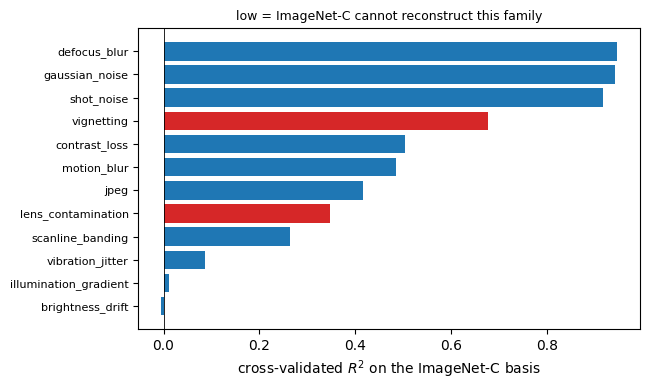


wrote /content/sdic/phase2/phase2_summary.json


In [11]:
#@title Item 2 — can ImageNet-C reconstruct each SDI-C family?
def damage(store,fams,y,b="resnet50.a1_in1k"):
    """Per-image mean NLL increase relative to clean, one vector per family."""
    Fc=store[("clean",0)][0][b]
    pr=make_pipeline(StandardScaler(),
                     LogisticRegression(max_iter=4000,class_weight="balanced")).fit(Fc,y)
    base=-np.log(np.clip(pr.predict_proba(Fc)[np.arange(len(y)),y],1e-12,None))
    out={}
    for f in fams:
        acc=[]
        for s in SEVERITIES:
            if (f,s) not in store: continue
            Fx=store[(f,s)][0][b]
            acc.append(-np.log(np.clip(pr.predict_proba(Fx)[np.arange(len(y)),y],1e-12,None))-base)
        out[f]=np.mean(acc,axis=0)
    return out

ys=N_y[H2H]
D_S=damage(NEU_S_H2H,TEST_FAMILIES+TRAIN_FAMILIES,ys)
D_I=damage(NEU_I_H2H,INC_FAMILIES,ys)
X=np.stack([D_I[f] for f in INC_FAMILIES],1)
rows=[]
for f in TEST_FAMILIES+TRAIN_FAMILIES:
    yv=D_S[f]
    pred=cross_val_predict(make_pipeline(StandardScaler(),RidgeCV(alphas=np.logspace(-2,4,25))),
                           X,yv,cv=5)
    r2=1-((yv-pred)**2).sum()/((yv-yv.mean())**2).sum()
    best=max(INC_FAMILIES,key=lambda g: abs(np.corrcoef(yv,D_I[g])[0,1]))
    rows.append(dict(sdic_family=f,cv_r2=r2,
                     closest_imagenetc=best,
                     r_closest=float(np.corrcoef(yv,D_I[best])[0,1])))
SPAN=pd.DataFrame(rows).sort_values("cv_r2")
display(SPAN.round(3))
SPAN.to_csv(OUT/"phase2_span.csv",index=False)

print("\nITEM 2 — cross-validated R^2 of each SDI-C family on the 15-family ImageNet-C basis")
print(f"  least reconstructable: {SPAN.iloc[0].sdic_family} (R2 = {SPAN.iloc[0].cv_r2:.3f})")
print(f"  most  reconstructable: {SPAN.iloc[-1].sdic_family} (R2 = {SPAN.iloc[-1].cv_r2:.3f})")
pre={"vignetting","lens_contamination"}
bottom=set(SPAN.head(4).sdic_family)
print(f"\n  registered prediction: vignetting and lens_contamination are least reconstructable")
print(f"  in the bottom four: {sorted(pre & bottom)}  -> prediction "
      f"{'HELD' if pre<=bottom else 'PARTIALLY HELD' if pre & bottom else 'FAILED'}")
if not (pre & bottom):
    print("  The diagnostic rescue in Section 6.8 is not supported. Demote SDI-C outright.")

fig,ax=plt.subplots(figsize=(6.6,4))
c=["#d62728" if f in pre else "#1f77b4" for f in SPAN.sdic_family]
ax.barh(range(len(SPAN)),SPAN.cv_r2,color=c)
ax.set_yticks(range(len(SPAN))); ax.set_yticklabels(SPAN.sdic_family,fontsize=8)
ax.set_xlabel("cross-validated $R^2$ on the ImageNet-C basis"); ax.axvline(0,c="k",lw=.6)
ax.set_title("low = ImageNet-C cannot reconstruct this family",fontsize=9)
plt.tight_layout(); plt.savefig(OUT/"phase2_span.png",dpi=200,bbox_inches="tight"); plt.show()

json.dump({"item1_rho":{ds:{"min":float(g.rho.min()),"max":float(g.rho.max()),
                            "median":float(g.rho.median()),
                            "intervals_excluding_zero":int((g.rho_lo>0).sum()),"n":len(g)}
                        for ds,g in V.groupby("dataset")},
           "item6_suite_icc":{"imagenetc":float(si),"sdic":float(ss),"ratio":float(si/ss)},
           "item2_span":SPAN.to_dict("records")},
          open(OUT/"phase2_summary.json","w"),indent=2)
print("\nwrote",OUT/"phase2_summary.json")

---

## Writing it up

**Item 1.** Replace *"one dataset"* in Limitations with the two-dataset range, and add Magnetic
Tile to Table 6. If the ranges overlap, say so — that is the finding. If Magnetic Tile's $\rho$ is
much larger or smaller, that is more interesting still, and the difference between a balanced
texture-classification task and a severely imbalanced localised-defect one is the obvious
explanation to offer.

**Item 2.** If the prediction holds, Section 6.8's diagnostic rescue becomes a measurement:
*"ImageNet-C reconstructs SDI-C's generic families at $R^2 > x$ but its contact-optics families at
only $R^2 < y$."* If it fails, delete the rescue and demote SDI-C to an instrument in Section 3 —
the reframe already prepares the manuscript for that, so it costs one paragraph.

**Item 3** remains the survey, which is literature work and cannot be run here.